In [22]:
from pathlib import Path
import random
import yaml
import numpy as np
import pandas as pd
import nibabel as nib
from PIL import Image

with open("config.yaml", "r") as f:
    CFG = yaml.safe_load(f)

print(CFG)

{'raw_dess_dir': 'data/skm-tea-data/nifti', 'raw_pd_dir': 'data/iu-dataset/nifti', 'npy_root': 'data/npy', 'manifest_root': 'data/manifests', 'plane': 'sagittal', 'image_size': 256, 'stack_depth': 1, 'center_only_label': True, 'normalize_percentiles': [1, 99], 'val_ratio': 0.1, 'seed': 42, 'max_dess_subjects': 5, 'max_pd_subjects': 5}


In [ ]:
from pathlib import Path
import nibabel as nib
import numpy as np
import pandas as pd

def find_nifti_files(root):
    root = Path(root)
    return sorted(list(root.glob("*.nii")) + list(root.glob("*.nii.gz")))

def get_subject_id(fp):
    name = fp.name
    if name.endswith(".nii.gz"):
        return name[:-7]
    if name.endswith(".nii"):
        return name[:-4]
    return fp.stem

def get_slice_axis_from_orientation(axcodes):
    for i, c in enumerate(axcodes):
        if c in ("L", "R"):
            return i
    raise ValueError(f"Could not find L/R axis in orientation {axcodes}")

def scan_domain(domain_name, root_dir, max_subjects):
    files = find_nifti_files(root_dir)
    print(f"[{domain_name}] found {len(files)} nifti files in {root_dir}")
    if max_subjects is not None:
        files = files[:max_subjects]
        print(f"[{domain_name}] using first {len(files)} files")

    rows = []
    for fp in files:
        img = nib.load(str(fp))
        data = img.get_fdata(dtype=np.float32)
        zooms = img.header.get_zooms()[:3]
        axcodes = nib.aff2axcodes(img.affine)
        slice_axis = get_slice_axis_from_orientation(axcodes)

        rows.append({
            "subject_id": get_subject_id(fp),
            "nifti_path": str(fp),
            "orientation": "".join(axcodes),
            "slice_axis": slice_axis,
            "shape_x": int(data.shape[0]),
            "shape_y": int(data.shape[1]),
            "shape_z": int(data.shape[2]),
            "spacing_x": float(zooms[0]),
            "spacing_y": float(zooms[1]),
            "spacing_z": float(zooms[2]),
        })
    return pd.DataFrame(rows)

dess_df = scan_domain("dess", CFG["raw_dess_dir"], CFG.get("max_dess_subjects"))
pd_df   = scan_domain("pd",   CFG["raw_pd_dir"],   CFG.get("max_pd_subjects"))

print("\nDESS")
display(dess_df.head())
print("\nPD")
display(pd_df.head())

[dess] found 21 nifti files in data/skm-tea-data/nifti
[dess] using first 5 files
[pd] found 22 nifti files in data/iu-dataset/nifti
[pd] using first 5 files

DESS


,subject_id,nifti_path,orientation,slice_axis,shape_x,shape_y,shape_z,spacing_x,spacing_y,spacing_z
0,MTR_005_Anonymized_2378615199_e1,data/skm-tea-data/nifti/MTR_005_Anonymized_237...,PSR,2,512,512,160,0.3125,0.3125,0.800655
1,MTR_006_Anonymized_419383518_e1,data/skm-tea-data/nifti/MTR_006_Anonymized_419...,PSR,2,512,512,160,0.3125,0.3125,0.799997
2,MTR_030_Anonymized_3161295654_e1,data/skm-tea-data/nifti/MTR_030_Anonymized_316...,PSR,2,512,512,160,0.3125,0.3125,0.799691
3,MTR_052_Anonymized_3584306213_e1,data/skm-tea-data/nifti/MTR_052_Anonymized_358...,PSR,2,512,512,160,0.3125,0.3125,0.800001
4,MTR_065_Anonymized_2473001408_e1,data/skm-tea-data/nifti/MTR_065_Anonymized_247...,PSR,2,512,512,160,0.3125,0.3125,0.800003



PD


,subject_id,nifti_path,orientation,slice_axis,shape_x,shape_y,shape_z,spacing_x,spacing_y,spacing_z
0,AC000550763509_SAG_PD_TSE_6,data/iu-dataset/nifti/AC000550763509_SAG_PD_TS...,PSR,2,384,384,36,0.390625,0.390625,3.600000
1,AC005135D3495B_SAG_PD_TSE_5,data/iu-dataset/nifti/AC005135D3495B_SAG_PD_TS...,PSR,2,768,768,31,0.182300,0.182300,3.600000
2,AC0407F05FAF53_SAG_PD_TSE_7,data/iu-dataset/nifti/AC0407F05FAF53_SAG_PD_TS...,PSR,2,768,768,30,0.208300,0.208300,3.600000
3,AC04433E37DB66_SAG_PD_TSE_5,data/iu-dataset/nifti/AC04433E37DB66_SAG_PD_TS...,PSR,2,768,768,30,0.208300,0.208300,3.600000
4,AC045F8F6ACBA7_SAG_PD_TSE_7,data/iu-dataset/nifti/AC045F8F6ACBA7_SAG_PD_TS...,PSR,2,768,768,42,0.221400,0.221400,3.600179


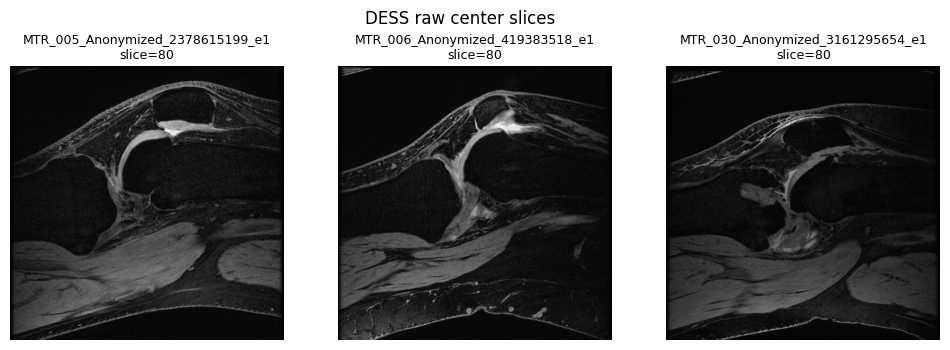

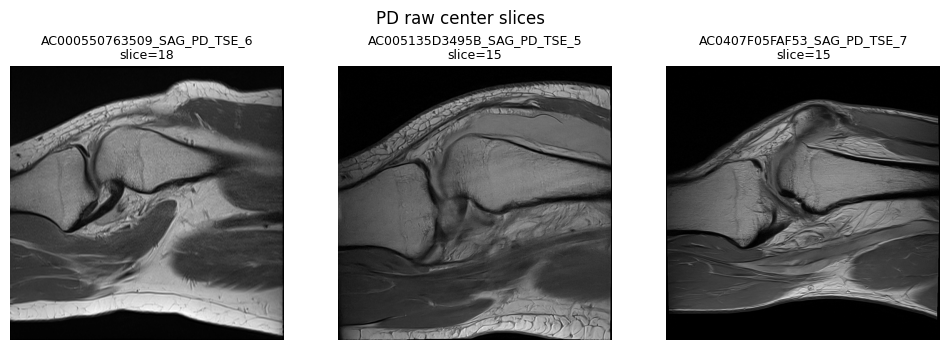

In [27]:
def get_slice(vol, axis, idx):
    if axis == 0:
        return vol[idx, :, :]
    elif axis == 1:
        return vol[:, idx, :]
    else:
        return vol[:, :, idx]

def show_center_slices(df, title, n=3):
    n = min(n, len(df))
    plt.figure(figsize=(4*n, 4))
    for i in range(n):
        row = df.iloc[i]
        img = nib.load(row["nifti_path"])
        vol = img.get_fdata(dtype=np.float32)
        axis = int(row["slice_axis"])
        idx = vol.shape[axis] // 2
        sl = get_slice(vol, axis, idx)

        plt.subplot(1, n, i+1)
        plt.imshow(sl, cmap="gray")
        plt.title(f'{row["subject_id"]}\nslice={idx}', fontsize=9)
        plt.axis("off")
    plt.suptitle(title)
    plt.show()

show_center_slices(dess_df, "DESS raw center slices")
show_center_slices(pd_df, "PD raw center slices")

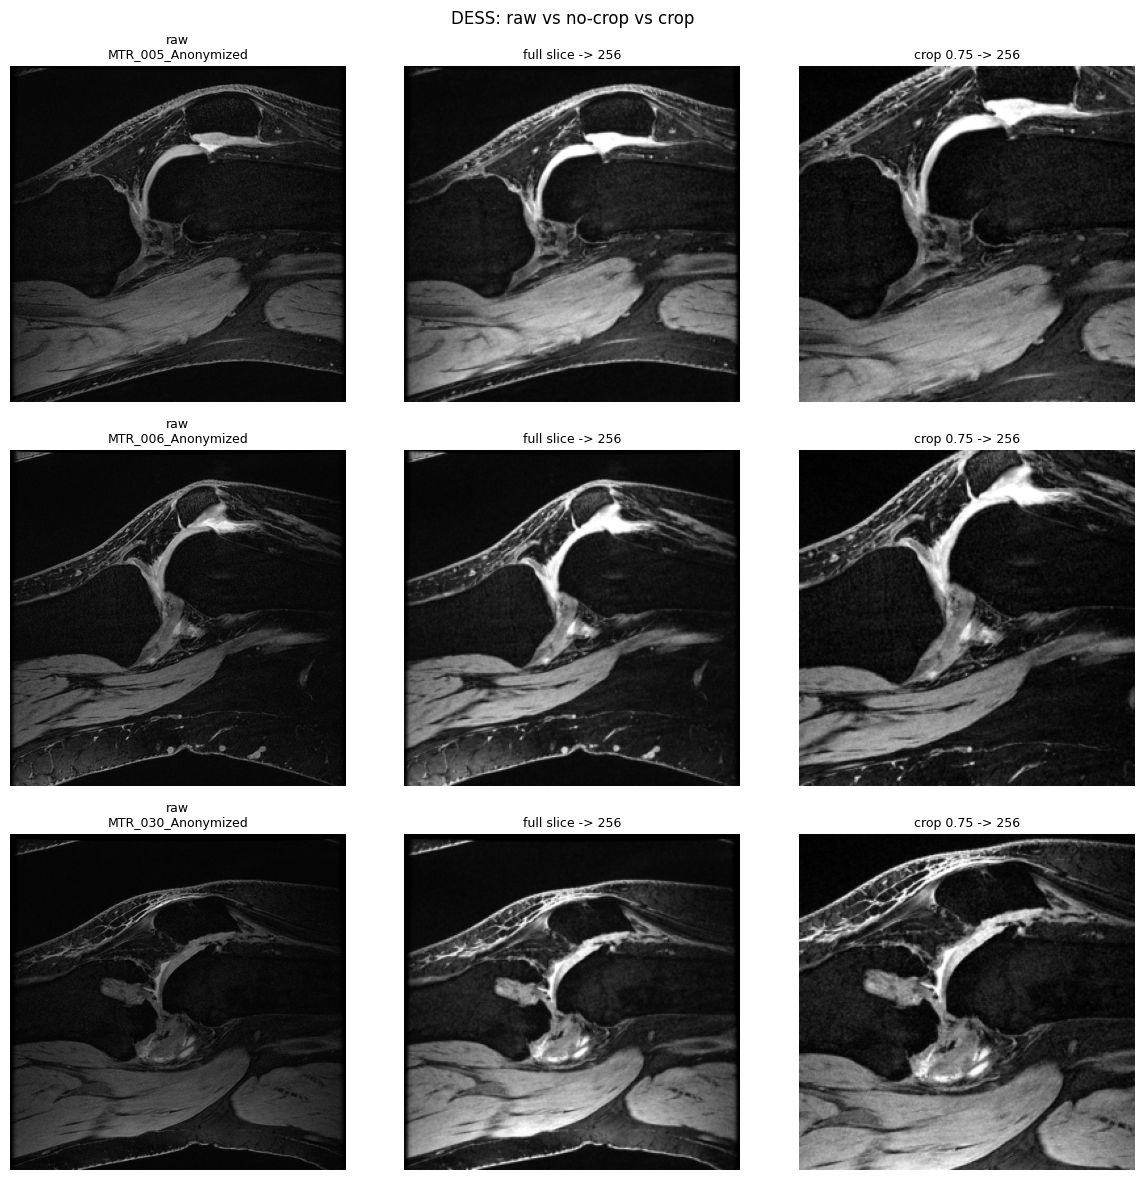

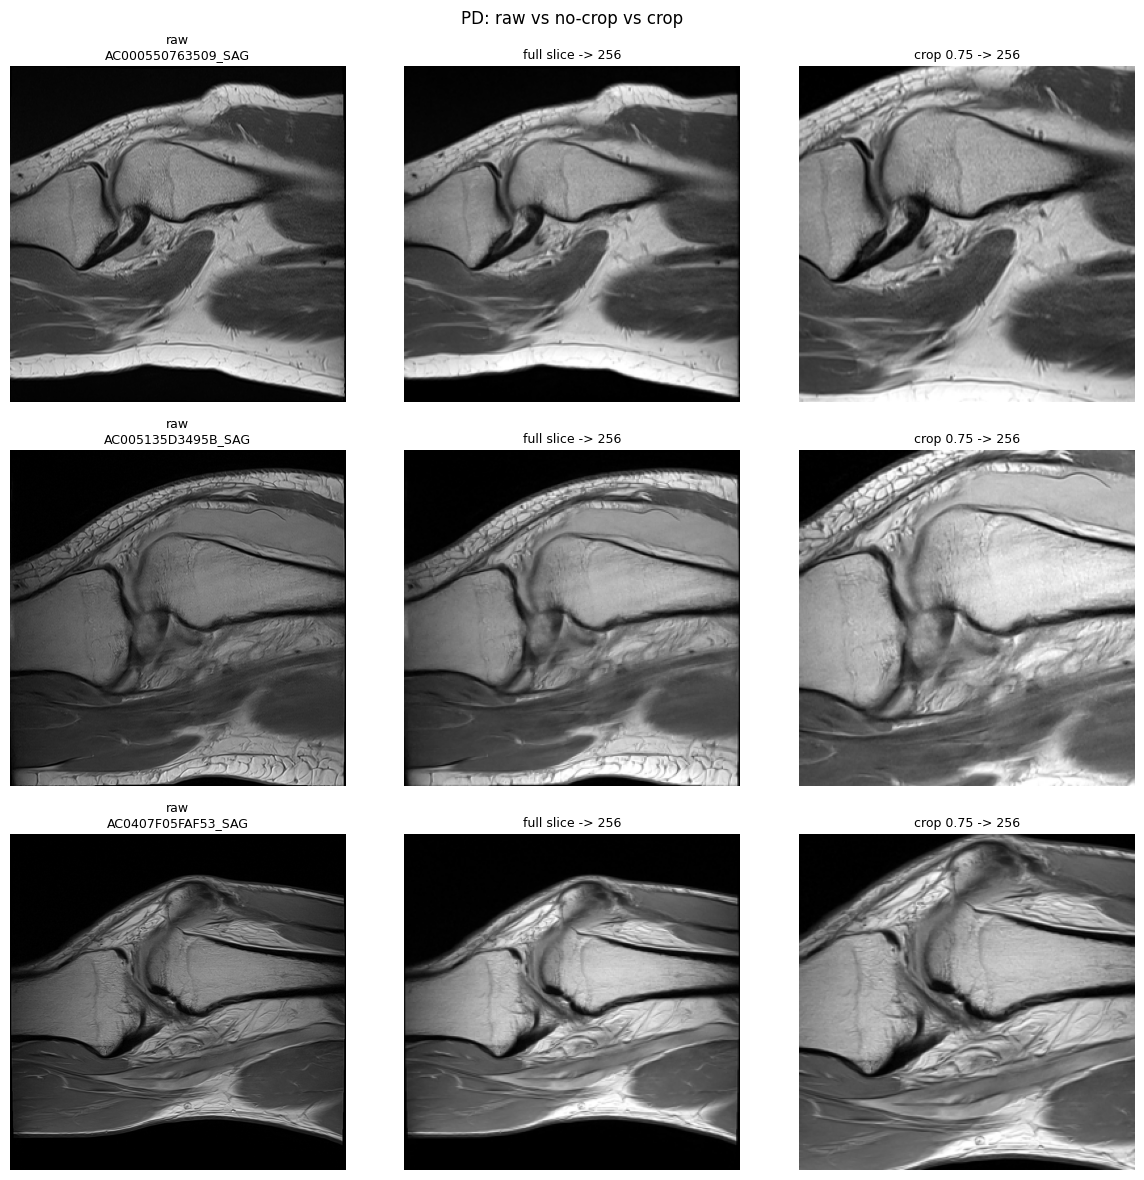

In [28]:
def fixed_center_crop(sl, crop_frac=0.75):
    h, w = sl.shape
    crop_size = int(min(h, w) * crop_frac)
    crop_size = max(64, crop_size)

    cy, cx = h // 2, w // 2
    y0 = max(0, cy - crop_size // 2)
    x0 = max(0, cx - crop_size // 2)
    y1 = min(h, y0 + crop_size)
    x1 = min(w, x0 + crop_size)

    y0 = max(0, y1 - crop_size)
    x0 = max(0, x1 - crop_size)

    cropped = sl[y0:y1, x0:x1]
    return cropped, (x0, y0, x1, y1)

def resize_to_256(sl):
    from PIL import Image
    x = sl.astype(np.float32)
    vals = x[x > 0]
    if vals.size > 0:
        lo, hi = np.percentile(vals, 1), np.percentile(vals, 99)
        x = np.clip(x, lo, hi)
    x = x - x.min()
    if x.max() > 0:
        x = x / x.max()
    x8 = (x * 255).astype(np.uint8)
    img = Image.fromarray(x8)
    img = img.resize((256, 256), resample=Image.BILINEAR)
    return np.asarray(img)

def show_before_after_crop(df, title, crop_frac=0.75, n=3):
    n = min(n, len(df))
    plt.figure(figsize=(12, 4*n))
    for i in range(n):
        row = df.iloc[i]
        img = nib.load(row["nifti_path"])
        vol = img.get_fdata(dtype=np.float32)
        axis = int(row["slice_axis"])
        idx = vol.shape[axis] // 2
        sl = get_slice(vol, axis, idx)

        no_crop = resize_to_256(sl)
        cropped, box = fixed_center_crop(sl, crop_frac=crop_frac)
        with_crop = resize_to_256(cropped)

        plt.subplot(n, 3, 3*i+1)
        plt.imshow(sl, cmap="gray")
        plt.title(f'raw\n{row["subject_id"][:18]}', fontsize=9)
        plt.axis("off")

        plt.subplot(n, 3, 3*i+2)
        plt.imshow(no_crop, cmap="gray")
        plt.title("full slice -> 256", fontsize=9)
        plt.axis("off")

        plt.subplot(n, 3, 3*i+3)
        plt.imshow(with_crop, cmap="gray")
        plt.title(f'crop {crop_frac} -> 256', fontsize=9)
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_before_after_crop(dess_df, "DESS: raw vs no-crop vs crop", crop_frac=0.75, n=3)
show_before_after_crop(pd_df, "PD: raw vs no-crop vs crop", crop_frac=0.75, n=3)

NO CROPPING NEEDED


In [29]:
import random
from pathlib import Path
import numpy as np
import pandas as pd
import nibabel as nib
from PIL import Image

SEED = int(CFG.get("seed", 42))
random.seed(SEED)
np.random.seed(SEED)

IMG_SIZE = int(CFG["image_size"])
VAL_RATIO = float(CFG.get("val_ratio", 0.1))
NORM_PCTS = CFG.get("normalize_percentiles", [1, 99])

NPY_ROOT = Path(CFG["npy_root"])
MANIFEST_ROOT = Path(CFG["manifest_root"])

for split in ["train", "val"]:
    for dom in ["A", "B"]:
        (NPY_ROOT / split / dom).mkdir(parents=True, exist_ok=True)
MANIFEST_ROOT.mkdir(parents=True, exist_ok=True)

def percentile_normalize_slice(x, lo=1, hi=99):
    vals = x[x > 0]
    if vals.size == 0:
        return np.zeros_like(x, dtype=np.float32)
    p_lo = np.percentile(vals, lo)
    p_hi = np.percentile(vals, hi)
    x = np.clip(x, p_lo, p_hi)
    x = (x - p_lo) / (p_hi - p_lo + 1e-8)
    x = x * 2.0 - 1.0
    return x.astype(np.float32)

def resize_slice(x, size=256):
    x01 = ((x + 1.0) / 2.0 * 255.0).clip(0, 255).astype(np.uint8)
    img = Image.fromarray(x01)
    img = img.resize((size, size), resample=Image.BILINEAR)
    y = np.asarray(img).astype(np.float32) / 255.0
    y = y * 2.0 - 1.0
    return y.astype(np.float32)

def iter_slices(vol, slice_axis):
    n = vol.shape[slice_axis]
    for idx in range(n):
        if slice_axis == 0:
            sl = vol[idx, :, :]
        elif slice_axis == 1:
            sl = vol[:, idx, :]
        else:
            sl = vol[:, :, idx]
        yield idx, sl

def keep_slice(sl):
    return np.mean(sl > 0) >= 0.02

def split_subjects(df):
    ids = df["subject_id"].tolist()
    ids = ids.copy()
    random.shuffle(ids)
    n_val = max(1, int(len(ids) * VAL_RATIO)) if len(ids) > 1 else 0
    val_ids = set(ids[:n_val])
    train_ids = set(ids[n_val:])
    return train_ids, val_ids

def export_domain(df, domain_name, out_domain):
    train_ids, val_ids = split_subjects(df)
    rows = []

    print(f"\n[{domain_name}] total subjects={len(df)} train={len(train_ids)} val={len(val_ids)}")

    for i, row in enumerate(df.itertuples(index=False), 1):
        fp = row.nifti_path
        subject_id = row.subject_id
        split = "val" if subject_id in val_ids else "train"

        print(f"[{domain_name}] {i}/{len(df)} {subject_id} split={split}")

        img = nib.load(fp)
        vol = img.get_fdata(dtype=np.float32)
        slice_axis = int(row.slice_axis)

        saved_this_subject = 0
        for slice_idx, sl in iter_slices(vol, slice_axis):
            if not keep_slice(sl):
                continue

            raw_h, raw_w = sl.shape
            sl = percentile_normalize_slice(sl, lo=NORM_PCTS[0], hi=NORM_PCTS[1])
            sl = resize_slice(sl, size=IMG_SIZE)

            out_name = f"{subject_id}_s{slice_idx:03d}.npy"
            out_path = NPY_ROOT / split / out_domain / out_name
            np.save(out_path, sl)

            rows.append({
                "subject_id": subject_id,
                "domain": domain_name,
                "split": split,
                "orig_nifti_path": fp,
                "orientation": row.orientation,
                "slice_axis": int(slice_axis),
                "slice_idx": int(slice_idx),
                "orig_vol_shape": str(tuple(vol.shape)),
                "raw_slice_h": int(raw_h),
                "raw_slice_w": int(raw_w),
                "saved_h": int(IMG_SIZE),
                "saved_w": int(IMG_SIZE),
                "slice_npy_path": str(out_path),
            })
            saved_this_subject += 1

        print(f"[{domain_name}] saved slices: {saved_this_subject}")

    out_df = pd.DataFrame(rows)
    out_csv = MANIFEST_ROOT / f"{domain_name}_slice_manifest.csv"
    out_df.to_csv(out_csv, index=False)
    print(f"[{domain_name}] manifest saved: {out_csv}")
    return out_df

dess_slice_df = export_domain(dess_df, "dess", "A")
pd_slice_df   = export_domain(pd_df, "pd", "B")

all_df = pd.concat([dess_slice_df, pd_slice_df], ignore_index=True)
all_df.to_csv(MANIFEST_ROOT / "all_slices_manifest.csv", index=False)

print("\n[all] total rows:", len(all_df))
display(all_df.head())


[dess] total subjects=5 train=4 val=1
[dess] 1/5 MTR_005_Anonymized_2378615199_e1 split=train
[dess] saved slices: 160
[dess] 2/5 MTR_006_Anonymized_419383518_e1 split=train
[dess] saved slices: 160
[dess] 3/5 MTR_030_Anonymized_3161295654_e1 split=train
[dess] saved slices: 160
[dess] 4/5 MTR_052_Anonymized_3584306213_e1 split=val
[dess] saved slices: 160
[dess] 5/5 MTR_065_Anonymized_2473001408_e1 split=train
[dess] saved slices: 160
[dess] manifest saved: data/manifests/dess_slice_manifest.csv

[pd] total subjects=5 train=4 val=1
[pd] 1/5 AC000550763509_SAG_PD_TSE_6 split=train
[pd] saved slices: 36
[pd] 2/5 AC005135D3495B_SAG_PD_TSE_5 split=train
[pd] saved slices: 31
[pd] 3/5 AC0407F05FAF53_SAG_PD_TSE_7 split=train
[pd] saved slices: 30
[pd] 4/5 AC04433E37DB66_SAG_PD_TSE_5 split=val
[pd] saved slices: 30
[pd] 5/5 AC045F8F6ACBA7_SAG_PD_TSE_7 split=train
[pd] saved slices: 42
[pd] manifest saved: data/manifests/pd_slice_manifest.csv

[all] total rows: 969


,subject_id,domain,split,orig_nifti_path,orientation,slice_axis,slice_idx,orig_vol_shape,raw_slice_h,raw_slice_w,saved_h,saved_w,slice_npy_path
0,MTR_005_Anonymized_2378615199_e1,dess,train,data/skm-tea-data/nifti/MTR_005_Anonymized_237...,PSR,2,0,"(512, 512, 160)",512,512,256,256,data/npy/train/A/MTR_005_Anonymized_2378615199...
1,MTR_005_Anonymized_2378615199_e1,dess,train,data/skm-tea-data/nifti/MTR_005_Anonymized_237...,PSR,2,1,"(512, 512, 160)",512,512,256,256,data/npy/train/A/MTR_005_Anonymized_2378615199...
2,MTR_005_Anonymized_2378615199_e1,dess,train,data/skm-tea-data/nifti/MTR_005_Anonymized_237...,PSR,2,2,"(512, 512, 160)",512,512,256,256,data/npy/train/A/MTR_005_Anonymized_2378615199...
3,MTR_005_Anonymized_2378615199_e1,dess,train,data/skm-tea-data/nifti/MTR_005_Anonymized_237...,PSR,2,3,"(512, 512, 160)",512,512,256,256,data/npy/train/A/MTR_005_Anonymized_2378615199...
4,MTR_005_Anonymized_2378615199_e1,dess,train,data/skm-tea-data/nifti/MTR_005_Anonymized_237...,PSR,2,4,"(512, 512, 160)",512,512,256,256,data/npy/train/A/MTR_005_Anonymized_2378615199...


In [30]:
from pathlib import Path
import numpy as np
import pandas as pd

for folder in [
    f'{CFG["npy_root"]}/train/A',
    f'{CFG["npy_root"]}/train/B',
    f'{CFG["npy_root"]}/val/A',
    f'{CFG["npy_root"]}/val/B',
]:
    count = len(list(Path(folder).glob("*.npy")))
    print(folder, count)

sample = sorted(Path(f'{CFG["npy_root"]}/train/A').glob("*.npy"))[0]
x = np.load(sample)

print("\nsample:", sample.name)
print("shape:", x.shape)
print("dtype:", x.dtype)
print("min:", float(x.min()))
print("max:", float(x.max()))

df = pd.read_csv(f'{CFG["manifest_root"]}/all_slices_manifest.csv')
print("\nmanifest rows:", len(df))
display(df.head())

data/npy/train/A 640
data/npy/train/B 139
data/npy/val/A 160
data/npy/val/B 30

sample: MTR_005_Anonymized_2378615199_e1_s000.npy
shape: (256, 256)
dtype: float32
min: -1.0
max: 1.0

manifest rows: 969


,subject_id,domain,split,orig_nifti_path,orientation,slice_axis,slice_idx,orig_vol_shape,raw_slice_h,raw_slice_w,saved_h,saved_w,slice_npy_path
0,MTR_005_Anonymized_2378615199_e1,dess,train,data/skm-tea-data/nifti/MTR_005_Anonymized_237...,PSR,2,0,"(512, 512, 160)",512,512,256,256,data/npy/train/A/MTR_005_Anonymized_2378615199...
1,MTR_005_Anonymized_2378615199_e1,dess,train,data/skm-tea-data/nifti/MTR_005_Anonymized_237...,PSR,2,1,"(512, 512, 160)",512,512,256,256,data/npy/train/A/MTR_005_Anonymized_2378615199...
2,MTR_005_Anonymized_2378615199_e1,dess,train,data/skm-tea-data/nifti/MTR_005_Anonymized_237...,PSR,2,2,"(512, 512, 160)",512,512,256,256,data/npy/train/A/MTR_005_Anonymized_2378615199...
3,MTR_005_Anonymized_2378615199_e1,dess,train,data/skm-tea-data/nifti/MTR_005_Anonymized_237...,PSR,2,3,"(512, 512, 160)",512,512,256,256,data/npy/train/A/MTR_005_Anonymized_2378615199...
4,MTR_005_Anonymized_2378615199_e1,dess,train,data/skm-tea-data/nifti/MTR_005_Anonymized_237...,PSR,2,4,"(512, 512, 160)",512,512,256,256,data/npy/train/A/MTR_005_Anonymized_2378615199...


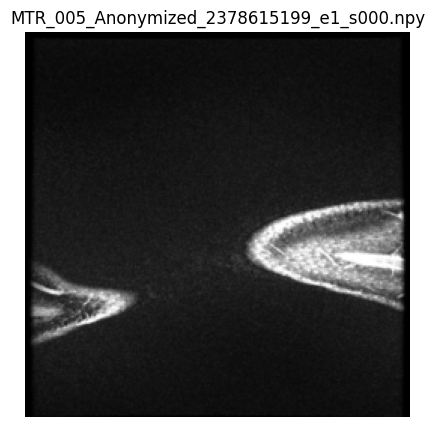

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))
plt.imshow(x, cmap="gray")
plt.title(sample.name)
plt.axis("off")
plt.show()